In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from utils.asymptotic_distribution import *

import pcms.tree

In [2]:
n_samples = 100_000
n_leaves = 500

In [3]:
sizes, size_counts = draw_subtree_size_counts(n_samples, n_leaves)

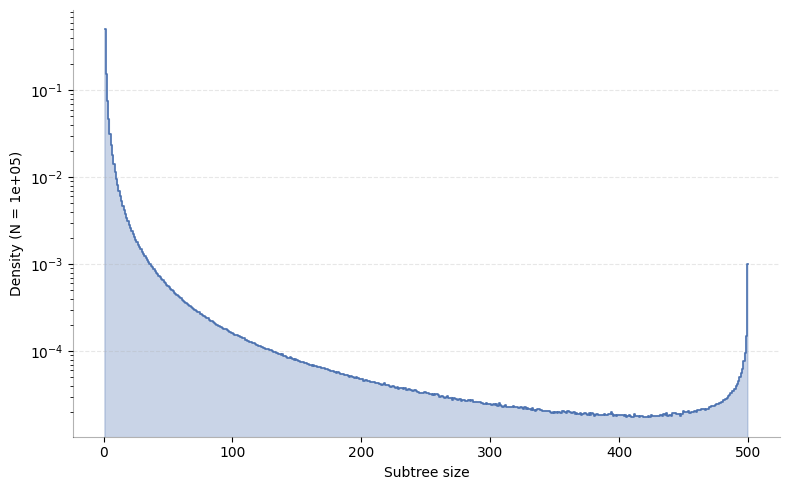

In [4]:
sort_idx = np.argsort(sizes)
sizes_sorted = sizes[sort_idx]
counts_sorted = size_counts[sort_idx]

bin_width = np.diff(sizes_sorted)[0] if len(sizes_sorted) > 1 else 1.0
total_count = np.sum(counts_sorted)
density = counts_sorted / (total_count * bin_width)

fig, ax = plt.subplots(figsize=(8, 5))

ax.step(sizes_sorted, density, where="mid", color="#4c72b0", linewidth=1.2)
ax.fill_between(sizes_sorted, density, step="mid", color="#4c72b0", alpha=0.3)

ax.set_yscale("log")
ax.set_xlabel("Subtree size")
ax.set_ylabel(f"Density (N = {n_samples:.0e})")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
k = 25
m = 5

In [6]:
vals, pair_counts = draw_subtree_pair_size_counts(n_samples=1_000_000, n_leaves=k+1, k=k, m=m)
k_counts = vals[:,0]
m_counts = vals[:,1]

cov_matrix = np.cov(k_counts, m_counts, fweights=pair_counts)
cov = cov_matrix[0, 1]

print(f"Cov(η_{k}, η_{m}): {cov}")

Cov(η_25, η_5): -0.01680230733230732


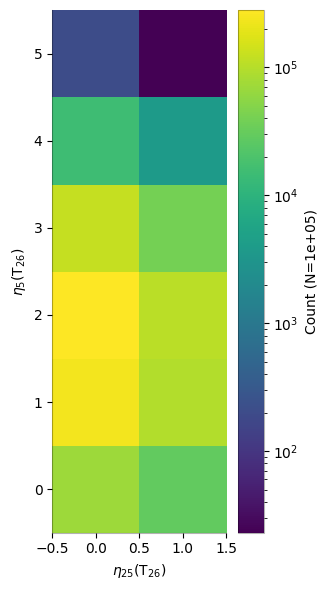

In [7]:
x = k_counts
y = m_counts

max_x = np.max(x) if len(x) > 0 else 0
max_y = np.max(y) if len(y) > 0 else 0

grid = np.zeros((max_x + 1, max_y + 1), dtype=np.float64)
grid[x, y] = pair_counts
grid[grid == 0] = np.nan

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    grid.T,
    origin="lower",
    cmap="viridis",
    norm=mcolors.LogNorm(vmin=np.nanmin(grid), vmax=np.nanmax(grid)),
    interpolation="nearest",
)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(f"Count (N={n_samples:.0e})")
cbar.outline.set_alpha(0.3)

ax.set_xlabel(rf"$\eta_{{{k}}}(\mathrm{{T}}_{{{k+1}}})$")
ax.set_ylabel(rf"$\eta_{{{m}}}(\mathrm{{T}}_{{{k+1}}})$")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)
ax.grid(False)

plt.tight_layout()
plt.show()

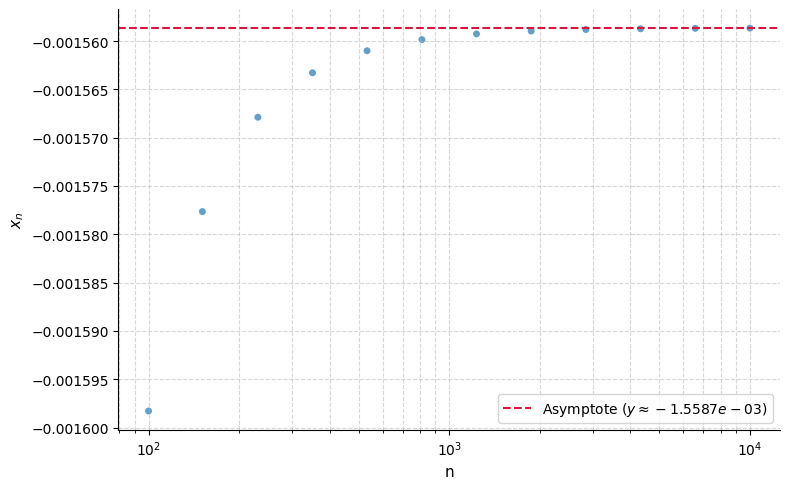

In [38]:
nrange = np.logspace(2, 4, 12, dtype=int)
xn_vals = np.array([compute_xn(n, k=k, m=m) for n in nrange])

asymptote_val = xn_vals[-1]

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(nrange, xn_vals, c="#1f77b4", alpha=0.7, edgecolors="none", s=25)
ax.axhline(
    y=asymptote_val,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f"Asymptote ($y \\approx {asymptote_val:.4e}$)",
)

ax.set_xscale("log")

ax.set_xlabel("n", fontsize=11)
ax.set_ylabel("$x_n$", fontsize=11)

ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=True, loc="best")

plt.tight_layout()
plt.show()

In [ ]:
import time

se_tol = 1e-3
nrange = np.logspace(2, 4, 12, dtype=int)
n0 = nrange[0]
gamma = 0.5

sampled_results = []
total_start = time.perf_counter()

for i, n in enumerate(nrange, start=1):
    step_start = time.perf_counter()
    
    vals, pair_counts = draw_subtree_pair_size_counts(
        n_samples=50_000,
        n_leaves=n, k=k, m=m
    )
    sampled_results.append((vals, pair_counts))
    
    step_time = time.perf_counter() - step_start
    print(f"[{i:02d}/{len(nrange)}] n = {n:<6d} | Step time: {step_time:.2f}s | Elapsed: {time.perf_counter() - total_start:.2f}s")

print(f"\nAll samples drawn in {time.perf_counter() - total_start:.2f}s total.")

[01/12] n = 100    | Step time: 0.80s | Elapsed: 0.80s
[02/12] n = 151    | Step time: 0.82s | Elapsed: 1.62s
[03/12] n = 231    | Step time: 0.86s | Elapsed: 2.48s
[04/12] n = 351    | Step time: 1.06s | Elapsed: 3.54s
[05/12] n = 533    | Step time: 1.14s | Elapsed: 4.68s
[06/12] n = 811    | Step time: 1.47s | Elapsed: 6.14s
[07/12] n = 1232   | Step time: 1.88s | Elapsed: 8.02s
[08/12] n = 1873   | Step time: 2.50s | Elapsed: 10.52s
[09/12] n = 2848   | Step time: 3.50s | Elapsed: 14.02s
[10/12] n = 4328   | Step time: 5.09s | Elapsed: 19.11s
[11/12] n = 6579   | Step time: 7.12s | Elapsed: 26.23s
[12/12] n = 10000  | Step time: 9.96s | Elapsed: 36.19s

All samples drawn in 36.19s total.


In [ ]:
cov = []
for vals, pair_counts in sampled_results:
    k_counts = vals[:, 0]
    m_counts = vals[:, 1]
    cov_matrix = np.cov(k_counts, m_counts, fweights=pair_counts)
    cov.append(cov_matrix[0, 1])
cov = np.array(cov)

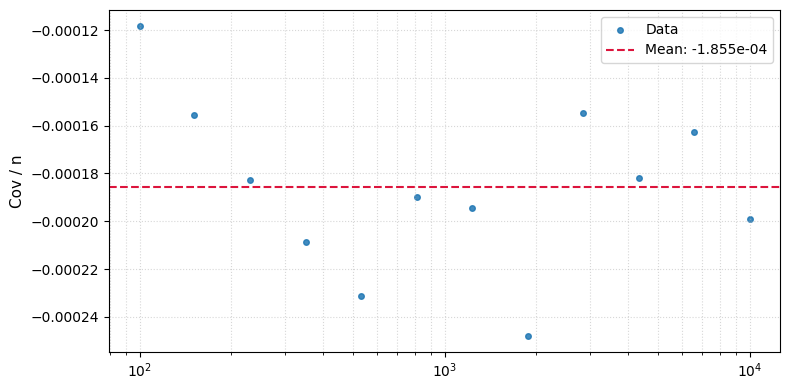

In [ ]:
y_vals = cov / nrange
mean_val = np.mean(y_vals)

fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(nrange, y_vals, s=16, color="#1f77b4", alpha=0.85, label="Data")
ax.axhline(
    mean_val, color="crimson", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.3e}"
)
ax.set_xscale("log")
ax.set_ylabel("Cov / n", fontsize=11)
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

In [49]:
def q(n,i):
    return n / harmonic_number(n-1) / 2 * (1 / i) * (1 / (n - i))

def draw_split(n, num_samples=1):
    cdf = np.array([q(n,i) for i in range(1,n)])
    cdf = np.cumsum(cdf)

    draws = np.ndarray(shape=(num_samples,), dtype=int)

    for i in range(num_samples):
        u = np.random.uniform()

        draw = 1
        while u >= cdf[draw-1]:
            draw += 1

        draws[i] = draw

    return draws if num_samples > 1 else int(draws[0])

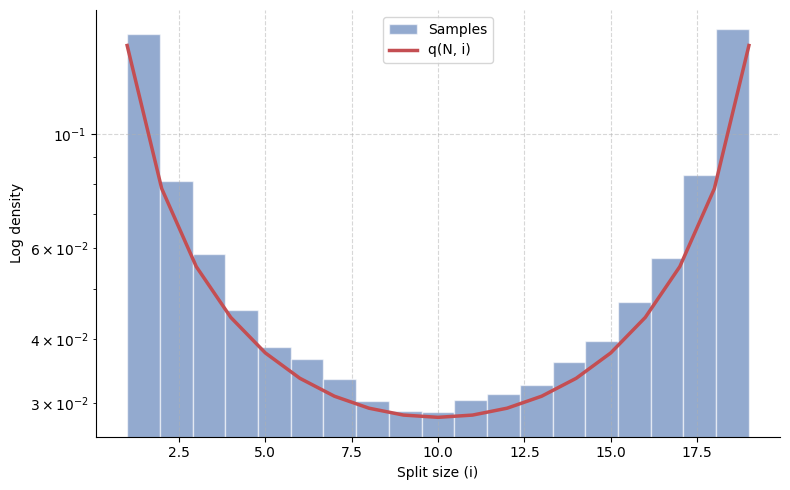

In [79]:
N = 20
nrange = np.arange(1, N)
num_samples = 100_000
draws = draw_split(N, num_samples=num_samples)
qvals = np.array([q(N, i) for i in nrange])

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    draws,
    bins=N-1,
    density=True,
    color="#4C72B0",
    edgecolor="white",
    alpha=0.6,
    label="Samples",
)
ax.plot(nrange, qvals, color="#C44E52", linewidth=2.5, label="q(N, i)")

ax.set_xlabel("Split size (i)")
ax.set_ylabel("Log density")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(frameon=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [80]:
def f(n,x):
    return 1/x + 1/(n-x)

def g(x):
    return 1/x

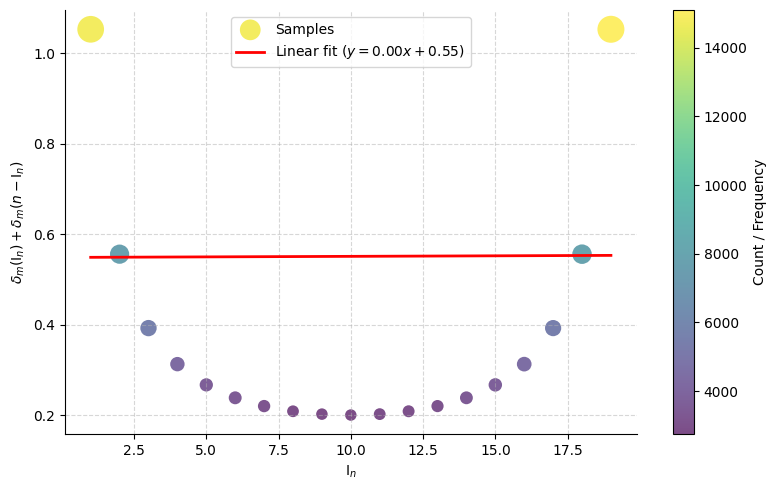

In [91]:
xs = draws
ys = np.array([f(N, x) for x in draws])

m, b = np.polyfit(xs, ys, 1)
x_line = np.linspace(xs.min(), xs.max(), 100)

xy_pairs, counts = np.unique(np.column_stack((xs, ys)), axis=0, return_counts=True)
x_unique, y_unique = xy_pairs[:, 0], xy_pairs[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    x_unique,
    y_unique,
    c=counts,
    s=counts / N / 2,
    cmap="viridis",
    alpha=0.7,
    edgecolors="none",
    label="Samples"
)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Count / Frequency")

ax.plot(
    x_line,
    m * x_line + b,
    color="red",
    linewidth=2,
    label=f"Linear fit ($y = {m:.2f}x {b:+.2f}$)"
)

ax.set_xlabel(r"$\mathrm{I}_n$")
ax.set_ylabel(r"$\delta_m(\mathrm{I}_n)+\delta_m(n-\mathrm{I}_n)$")
ax.grid(True, linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True, loc="upper center")

plt.tight_layout()
plt.show()

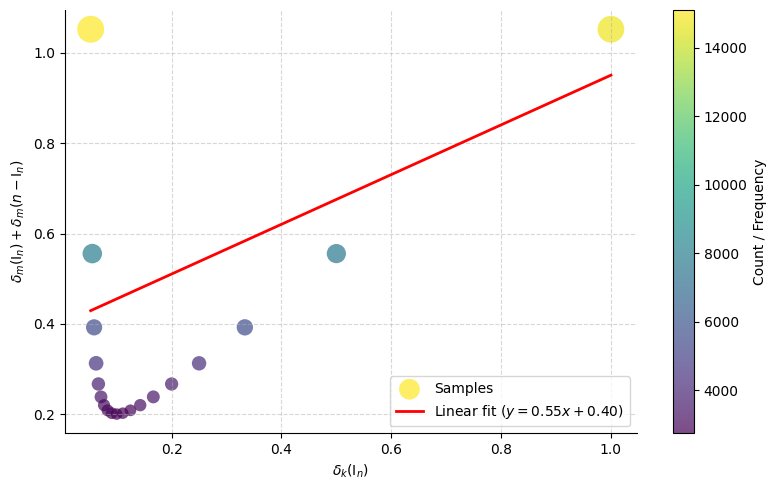

In [96]:
xs = np.array([g(x) for x in draws])
ys = np.array([f(N, x) for x in draws])

m, b = np.polyfit(xs, ys, 1)
x_line = np.linspace(xs.min(), xs.max(), 100)

xy_pairs, counts = np.unique(np.column_stack((xs, ys)), axis=0, return_counts=True)
x_unique, y_unique = xy_pairs[:, 0], xy_pairs[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    x_unique,
    y_unique,
    c=counts,
    s=counts / N / 2,
    cmap="viridis",
    alpha=0.7,
    edgecolors="none",
    label="Samples"
)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Count / Frequency")

ax.plot(
    x_line,
    m * x_line + b,
    color="red",
    linewidth=2,
    label=f"Linear fit ($y = {m:.2f}x {b:+.2f}$)"
)

ax.set_xlabel(r"$\delta_k(\mathrm{I}_n)$")
ax.set_ylabel(r"$\delta_m(\mathrm{I}_n)+\delta_m(n-\mathrm{I}_n)$")
ax.grid(True, linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True, loc="lower right")

plt.tight_layout()
plt.show()